   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]

Informações do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeI

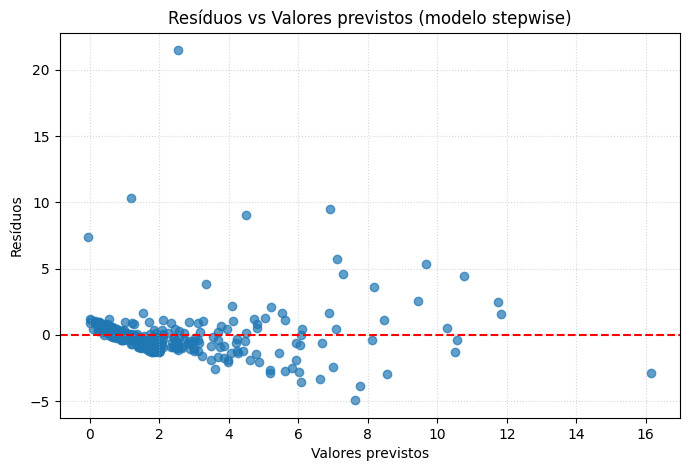

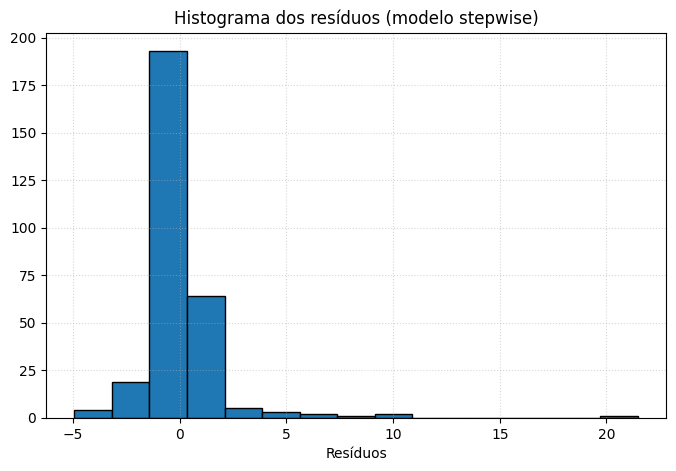


Lambda Box-Cox (ótimo): -0.44109784753625625

================ MODELO COM BOX-COX (y transformado) ================

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     105.3
Date:                Fri, 29 May 2026   Prob (F-statistic):           6.39e-63
Time:                        17:31:00   Log-Likelihood:                -136.14
No. Observations:                 294   AIC:                             284.3
Df Residuals:                     288   BIC:                             306.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

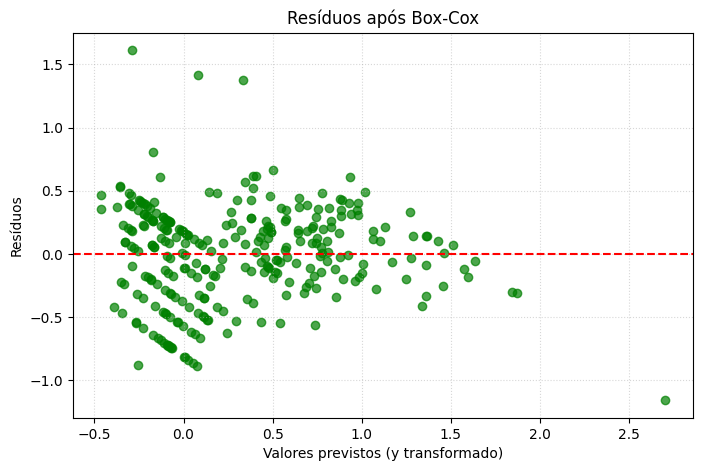

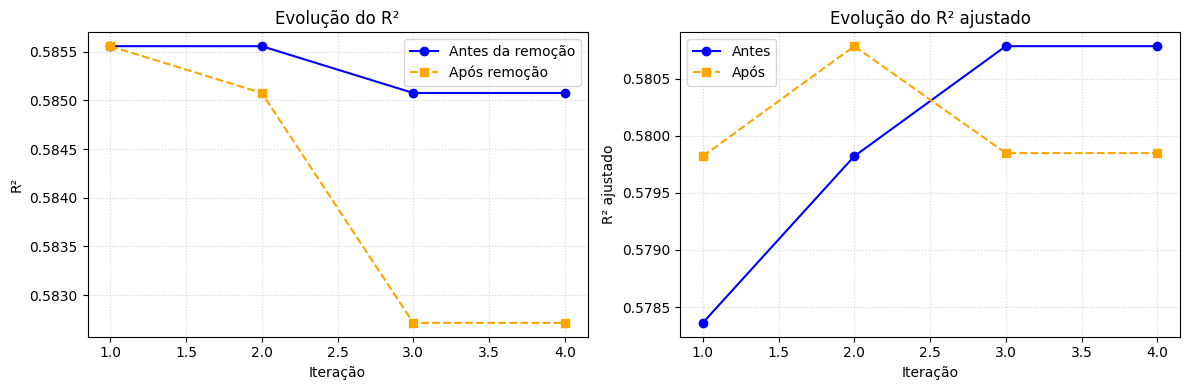

In [7]:
# ============================================================
# REGRESSÃO MÚLTIPLA + STEPWISE BACKWARD + BOX-COX
# Dataset: Chronic Kidney Disease (taxa de filtração glomerular)
# ============================================================
# Objetivo: prever creatinina sérica (sc) a partir de variáveis clínicas
# Etapas: 1) regressão inicial, 2) seleção backward stepwise,
#         3) análise de resíduos, 4) transformação Box-Cox,
#         5) comparação de modelos
# ============================================================

# Instalar bibliotecas se necessário (descomente se for rodar pela primeira vez)
# pip install pandas numpy statsmodels scipy scikit-learn matplotlib seaborn

# Importa as bibliotecas necessárias
import pandas as pd          # manipulação de dados (DataFrames)
import numpy as np           # operações numéricas e arrays
import statsmodels.api as sm # modelos de regressão e testes estatísticos
from scipy import stats      # transformação Box-Cox e funções estatísticas
import matplotlib.pyplot as plt  # gráficos e visualizações

# ============================================================
# 1. CARREGAR O DATASET
# ============================================================

# URL pública do arquivo CSV (huggingface)
url = "https://huggingface.co/spaces/aswatht/ehr/resolve/main/kidney_disease.csv"

# Carrega o dataset:
# - na_values='?' : trata interrogações como valores ausentes (NaN)
# - low_memory=False : evita warnings de tipos mistos durante a leitura
df = pd.read_csv(url, na_values='?', low_memory=False)

# Exibe as primeiras 5 linhas para inspeção visual
print(df.head())

# Exibe informações gerais: tipos de dados, número de não-nulos, memória
print("\nInformações do dataset:\n")
print(df.info())

# Lista todas as colunas disponíveis
print("\nColunas disponíveis:\n")
print(df.columns.tolist())

# ============================================================
# 2. SELECIONAR VARIÁVEIS DE INTERESSE
# ============================================================

# Variável resposta (dependente) = creatinina sérica (sc)
y = df["sc"]

# Variáveis explicativas (independentes) escolhidas
X = df[[
    "age",   # idade (anos)
    "bp",    # pressão arterial (mm/Hg)
    "bgr",   # glicose sanguínea (mg/dL)
    "bu",    # ureia no sangue (mg/dL)
    "hemo"   # hemoglobina (g/dL)
]]

# Converte as colunas para tipo numérico; erros de conversão viram NaN
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Junta X e y em um único DataFrame e remove linhas com qualquer NaN
dados = pd.concat([X, y], axis=1).dropna()

# Reatribui X e y já sem valores faltantes
X = dados[[
    "age",
    "bp",
    "bgr",
    "bu",
    "hemo"
]]
y = dados["sc"]

# Mostra as primeiras linhas do dataset limpo e sua dimensão
print("\nDataset final após limpeza:")
print(dados.head())
print("\nShape:", dados.shape)

# ============================================================
# 3. REGRESSÃO MÚLTIPLA INICIAL (modelo completo)
# ============================================================

# Adiciona uma coluna de 1's (intercepto/constante) à matriz X
X_const = sm.add_constant(X)

# Ajusta o modelo OLS (Ordinary Least Squares) e exibe sumário
modelo = sm.OLS(y, X_const).fit()

print("\n================ MODELO INICIAL ================\n")
print(modelo.summary())

# ============================================================
# 4. STEPWISE BACKWARD ELIMINATION (seleção regressiva)
# ============================================================

def backward_stepwise(df, target_col, feature_cols, significance_level=0.05):
    """
    Executa a eliminação regressiva (backward) com base no p-valor.

    Parâmetros:
    - df: DataFrame contendo todas as variáveis (preditores + alvo)
    - target_col: nome da coluna alvo (string)
    - feature_cols: lista com nomes das colunas preditoras iniciais
    - significance_level: limiar de significância (padrão 0.05)

    Retorna:
    - final_model: modelo OLS ajustado com as variáveis selecionadas
    - history: lista de dicionários com métricas de cada iteração
    """

    # Copia a lista de features iniciais (será modificada)
    current_features = feature_cols.copy()

    # Lista para armazenar o histórico das remoções
    history = []

    # Cabeçalho do processo
    print("="*70)
    print("INÍCIO DO STEPWISE BACKWARD ELIMINATION")
    print(f"Nível de significância para remoção: {significance_level}")
    print("="*70)

    iteration = 1   # contador de iterações

    # Loop principal: repete até que todas as variáveis tenham p-valor ≤ limiar
    while True:
        # Prepara os dados do modelo atual
        X_curr = df[current_features]
        X_curr = sm.add_constant(X_curr)   # adiciona intercepto
        y_curr = df[target_col]

        # Ajusta o modelo OLS
        model = sm.OLS(y_curr, X_curr).fit()

        # Extrai métricas de qualidade
        r2 = model.rsquared
        r2_adj = model.rsquared_adj
        aic = model.aic
        bic = model.bic

        # Obtém p-valores de todas as variáveis (exceto a constante)
        p_values = model.pvalues.drop('const')

        # Identifica a variável com o maior p-valor
        max_p_value = p_values.max()
        max_p_feature = p_values.idxmax()

        # Exibe informações da iteração atual
        print(f"\n📊 Iteração {iteration} | Features: {len(current_features)}")
        print(f"   R² = {r2:.4f}  |  R²_adj = {r2_adj:.4f}  |  AIC = {aic:.2f}  |  BIC = {bic:.2f}")
        print(f"   P-valores: {', '.join([f'{col}={pval:.4f}' for col, pval in p_values.items()])}")

        # Critério de parada: maior p-valor já é ≤ nível de significância
        if max_p_value <= significance_level:
            print(f"\n✅ PARADA: Maior p-valor = {max_p_value:.4f} <= {significance_level}. Nenhuma variável a remover.")
            break

        # Se chegou aqui, remove a variável com maior p-valor
        print(f"\n❌ Removendo '{max_p_feature}' (p-valor = {max_p_value:.4f} > {significance_level})")

        # Cria lista de features sem a variável removida
        temp_features = [f for f in current_features if f != max_p_feature]

        # Ajusta modelo temporário sem essa variável para ver o impacto
        X_temp = df[temp_features]
        X_temp = sm.add_constant(X_temp)
        model_temp = sm.OLS(y_curr, X_temp).fit()

        # Métricas após a remoção
        r2_new = model_temp.rsquared
        r2_adj_new = model_temp.rsquared_adj
        aic_new = model_temp.aic
        bic_new = model_temp.bic

        # Mostra o impacto da remoção nas métricas
        print(f"   Impacto da remoção:")
        print(f"      R²: {r2:.4f} → {r2_new:.4f} (Δ = {r2_new - r2:.4f})")
        print(f"      R²_adj: {r2_adj:.4f} → {r2_adj_new:.4f} (Δ = {r2_adj_new - r2_adj:.4f})")
        print(f"      AIC: {aic:.2f} → {aic_new:.2f} (Δ = {aic_new - aic:.2f})")

        # Comentário qualitativo sobre a variação do R² ajustado
        if (r2_adj_new - r2_adj) > 0:
            print(f"      ✅ O R² ajustado aumentou — remoção benéfica.")
        elif (r2_adj_new - r2_adj) > -0.01:
            print(f"      ⚠️ Pequena queda no R² ajustado (menos de 0,01) — remoção aceitável.")
        else:
            print(f"      ❌ Queda significativa — considere manter a variável.")

        # Armazena informações dessa iteração no histórico
        history.append({
            'iteration': iteration,
            'removed': max_p_feature,
            'pvalue': max_p_value,
            'features_before': current_features.copy(),
            'r2_before': r2,
            'r2_adj_before': r2_adj,
            'aic_before': aic,
            'bic_before': bic,
            'features_after': temp_features.copy(),
            'r2_after': r2_new,
            'r2_adj_after': r2_adj_new,
            'aic_after': aic_new,
            'bic_after': bic_new
        })

        # Atualiza a lista de features para a próxima iteração
        current_features = temp_features
        iteration += 1

    # Ao sair do loop, ajusta o modelo final com as features selecionadas
    X_final = sm.add_constant(df[current_features])
    final_model = sm.OLS(y_curr, X_final).fit()

    # Resumo final do stepwise
    print("\n" + "="*70)
    print("RESUMO FINAL DO STEPWISE")
    print("="*70)
    print(f"Variáveis selecionadas: {current_features if current_features else 'Nenhuma (apenas constante)'}")
    print(f"Quantidade de variáveis: {len(current_features)}")
    print(f"R² final: {final_model.rsquared:.4f}")
    print(f"R² ajustado final: {final_model.rsquared_adj:.4f}")
    print(f"AIC final: {final_model.aic:.2f}")
    print(f"BIC final: {final_model.bic:.2f}")
    print("="*70)

    # Retorna o modelo final e o histórico para análises posteriores
    return final_model, history

# Lista com os nomes das variáveis preditoras iniciais
features_iniciais = ["age", "bp", "bgr", "bu", "hemo"]

# Executa o stepwise backward usando o DataFrame 'dados'
modelo_final, historico = backward_stepwise(dados, target_col="sc", feature_cols=features_iniciais)

# Exibe o sumário completo do modelo final selecionado
print("\n================ MODELO FINAL STEPWISE ================\n")
print(modelo_final.summary())

# ============================================================
# 5. EXTRAÇÃO DOS RESÍDUOS E VALORES PREVISTOS (modelo final)
# ============================================================

# Resíduos (erros) do modelo final
residuos = modelo_final.resid
# Valores ajustados (previstos) pelo modelo final
valores_previstos = modelo_final.fittedvalues

# ============================================================
# 6. GRÁFICO DE RESÍDUOS VS VALORES PREVISTOS
# ============================================================
# Este gráfico ajuda a verificar homocedasticidade (variância constante dos erros)
plt.figure(figsize=(8,5))
plt.scatter(valores_previstos, residuos, alpha=0.7)  # pontos semi-transparentes
plt.axhline(y=0, linestyle='--', color='red')        # linha horizontal em zero
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores previstos (modelo stepwise)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# ============================================================
# 7. HISTOGRAMA DOS RESÍDUOS
# ============================================================
# Avalia visualmente a normalidade da distribuição dos erros
plt.figure(figsize=(8,5))
plt.hist(residuos, bins=15, edgecolor='black')
plt.xlabel("Resíduos")
plt.title("Histograma dos resíduos (modelo stepwise)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# ============================================================
# 8. TRANSFORMAÇÃO BOX-COX NA VARIÁVEL RESPOSTA
# ============================================================
# A transformação Box-Cox estabiliza a variância e torna os resíduos mais normais

# Box-Cox exige valores estritamente positivos. Se houver zero ou negativo, soma-se 1.
if (y <= 0).any():
    y_boxcox = y + 1
else:
    y_boxcox = y.copy()

# Aplica a transformação Box-Cox; retorna os dados transformados e o lambda ótimo
y_transformado, lambda_boxcox = stats.boxcox(y_boxcox)

print("\nLambda Box-Cox (ótimo):", lambda_boxcox)
# Interpretação: lambda próximo de 0 sugere log natural; negativo sugere potência negativa.

# ============================================================
# 9. REGRESSÃO COM A RESPOSTA TRANSFORMADA (BOX-COX)
# ============================================================
# Usamos as mesmas variáveis X (as 5 originais) mas com y transformado
modelo_boxcox = sm.OLS(y_transformado, sm.add_constant(X)).fit()

print("\n================ MODELO COM BOX-COX (y transformado) ================\n")
print(modelo_boxcox.summary())

# ============================================================
# 10. RESÍDUOS APÓS BOX-COX
# ============================================================
# Verifica se a transformação melhorou a distribuição dos resíduos
residuos_boxcox = modelo_boxcox.resid
previstos_boxcox = modelo_boxcox.fittedvalues

plt.figure(figsize=(8,5))
plt.scatter(previstos_boxcox, residuos_boxcox, alpha=0.7, color='green')
plt.axhline(y=0, linestyle='--', color='red')
plt.xlabel("Valores previstos (y transformado)")
plt.ylabel("Resíduos")
plt.title("Resíduos após Box-Cox")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# ============================================================
# (EXTRA) GRÁFICOS DE EVOLUÇÃO DAS MÉTRICAS DURANTE O STEPWISE
# ============================================================
# Mostra como R² e R² ajustado se comportaram a cada remoção

# Prepara os dados para os gráficos a partir do histórico
iters = [h['iteration'] for h in historico]                     # números das iterações
r2_before = [h['r2_before'] for h in historico]                 # R² antes da remoção
r2_after = [h['r2_after'] for h in historico] + [modelo_final.rsquared]  # após cada remoção + final

r2_adj_before = [h['r2_adj_before'] for h in historico]         # R² ajustado antes
r2_adj_after = [h['r2_adj_after'] for h in historico] + [modelo_final.rsquared_adj]  # após + final

# Cria uma figura com dois subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Gráfico do R²
axes[0].plot(range(1, len(r2_before)+2), r2_before + [r2_before[-1]],
             'o-', label='Antes da remoção', color='blue')
axes[0].plot(range(1, len(r2_after)+1), r2_after,
             's--', label='Após remoção', color='orange')
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('R²')
axes[0].set_title('Evolução do R²')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

# Gráfico do R² ajustado
axes[1].plot(range(1, len(r2_adj_before)+2), r2_adj_before + [r2_adj_before[-1]],
             'o-', label='Antes', color='blue')
axes[1].plot(range(1, len(r2_adj_after)+1), r2_adj_after,
             's--', label='Após', color='orange')
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('R² ajustado')
axes[1].set_title('Evolução do R² ajustado')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

# Ajusta o layout e exibe os gráficos
plt.tight_layout()
plt.show()